# Clustering Model Comparison for Typhoon Impact Profiling

## Overview
This notebook performs a **comprehensive comparison of multiple clustering algorithms** to identify the optimal model for classifying typhoon impact events in the Philippines. The comparison evaluates 7 key models using standard clustering metrics (Silhouette Score, Calinski-Harabasz Index, Davies-Bouldin Index) to determine the best-performing algorithm.

---

## Pipeline Architecture

```
┌─────────────────────────────────────────────────────────────────────────────────┐
│                    CLUSTERING MODEL COMPARISON PIPELINE                         │
├─────────────────────────────────────────────────────────────────────────────────┤
│                                                                                 │
│  ┌─────────────┐    ┌──────────────┐    ┌─────────────┐    ┌─────────────────┐  │
│  │   INPUT     │───▶│   PREPROCESS │───▶│     PCA     │───▶│  MULTI-MODEL    │  │
│  │   DATA      │    │   & SCALE    │    │  REDUCTION  │    │   CLUSTERING    │  │
│  └─────────────┘    └──────────────┘    └─────────────┘    └────────┬────────┘  │
│                                                                      │          │
│                                    ┌─────────────────────────────────┘          │
│                                    ▼                                            │
│  ┌──────────────────────────────────────────────────────────────────────────┐   │
│  │                         CLUSTERING ALGORITHMS                            │   │
│  │  ┌─────────┐ ┌─────────┐ ┌─────────┐ ┌─────────┐ ┌─────────┐ ┌─────────┐ │   │
│  │  │ KMeans  │ │ KMeans  │ │ DBSCAN  │ │  Agglo  │ │  Agglo  │ │   GMM   │ │   │
│  │  │ Default │ │ Optuna  │ │ Optuna  │ │  Ward   │ │Complete │ │full/diag│ │   │
│  │  └─────────┘ └─────────┘ └─────────┘ └─────────┘ └─────────┘ └─────────┘ │   │
│  └──────────────────────────────────────────────────────────────────────────┘   │
│                                    │                                            │
│                                    ▼                                            │
│  ┌─────────────┐    ┌──────────────┐    ┌─────────────┐    ┌─────────────────┐  │
│  │   OUTPUT    │◀───│   RANKING    │◀───│  METRICS    │◀───│  VISUALIZATION  │  │
│  │   REPORT    │    │  & SELECTION │    │  EVALUATION │    │   COMPARISON    │  │
│  └─────────────┘    └──────────────┘    └─────────────┘    └─────────────────┘  │
│                                                                                 │
└─────────────────────────────────────────────────────────────────────────────────┘
```

---

## Input

| File | Description |
|------|-------------|
| `data/typhoon_impact_with_extreme_weather.csv` | Preprocessed typhoon impact dataset containing meteorological data, damage metrics, and affected population statistics |

### Input Features:
- **Impact Metrics**: `Families`, `Person`, `Dead`, `Injured/Ill`, `Missing`, `Totally`, `Partially`, `Cost`
- **Weather Data**: `Max_Sustained_Wind_kph`, `Max_24hr_Rainfall_mm`, `Total_Storm_Rainfall_mm`, `Min_Pressure_hPa`
- **Temporal Data**: `Duration_in_PAR_Hours`
- **Categorical**: `Region`, `Typhoon_Type`

---

## Output

| Output | Description |
|--------|-------------|
| Model Comparison Table | Side-by-side metrics for all 7 clustering algorithms |
| 2D/3D Visualizations | PCA projections showing cluster assignments for each model |
| Final Ranking | Combined normalized score ranking of all models |
| Best Model Recommendation | Optimal algorithm based on evaluation metrics |

---

## Models Compared

| # | Model | Type | Hyperparameter Optimization |
|---|-------|------|-----------------------------|
| 1 | **KMeans (Default)** | Centroid-based | Default parameters |
| 2 | **KMeans (Optuna)** | Centroid-based | Optuna-optimized (`init`, `n_init`, `max_iter`) |
| 3 | **DBSCAN (Optuna)** | Density-based | Optuna-optimized (`eps`, `min_samples`) |
| 4 | **Agglomerative (Ward)** | Hierarchical | Ward linkage |
| 5 | **Agglomerative (Complete)** | Hierarchical | Complete linkage |
| 6 | **GMM (Full)** | Probabilistic | Full covariance matrix |
| 7 | **GMM (Diag)** | Probabilistic | Diagonal covariance matrix |

---

## Evaluation Metrics

| Metric | Description | Optimal Value |
|--------|-------------|---------------|
| **Silhouette Score** | Measures cluster cohesion and separation | Higher is better (-1 to 1) |
| **Calinski-Harabasz Index** | Ratio of between-cluster to within-cluster variance | Higher is better |
| **Davies-Bouldin Index** | Average similarity between clusters | Lower is better |
| **Combined Score** | Normalized weighted combination of all metrics | Higher is better |

---

## Pipeline Steps

1. **Data Loading & Preprocessing**
   - Load typhoon impact dataset
   - Drop irrelevant columns
   - Encode categorical variables (Region, Typhoon Type)

2. **Feature Scaling**
   - Apply StandardScaler for normalization

3. **Dimensionality Reduction (PCA)**
   - Reduce features while retaining 95% variance
   - Generate 2D and 3D visualizations

4. **Multi-Model Training**
   - Train all 7 clustering models
   - Apply Optuna optimization where applicable

5. **Metrics Evaluation**
   - Calculate Silhouette, Calinski-Harabasz, Davies-Bouldin scores
   - Record execution time and cluster counts

6. **Visualization Comparison**
   - 2D PCA scatter plots for all models
   - 3D PCA scatter plots for all models
   - Separate DBSCAN visualization (handles noise points)

7. **Final Ranking**
   - Normalize all metrics to 0-1 scale
   - Calculate combined score
   - Rank models and recommend best performer

---

## Expected Results Summary

| Rank | Model | Silhouette | Calinski-H | Davies-B |
|------|-------|------------|------------|----------|
| 1 | DBSCAN (Optuna) | ~0.71 | ~1763.69 | ~0.45 |
| 2 | Agglomerative (Complete) | ~0.83 | ~89.28 | ~0.37 |
| 3 | KMeans (Optuna) | ~0.15 | ~225.33 | ~2.09 |
| 4 | KMeans (Default) | ~0.14 | ~220.34 | ~2.18 |
| 5 | Agglomerative (Ward) | ~0.13 | ~193.62 | ~2.27 |
| 6 | GMM (Diag) | ~0.13 | ~164.96 | ~2.37 |
| 7 | GMM (Full) | ~0.13 | ~161.12 | ~2.39 |

---

## Dependencies

```python
pandas, numpy, scikit-learn, optuna, xgboost, matplotlib, seaborn
```

In [109]:
# Core data manipulation and numerical libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn components
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import DBSCAN

# Hyperparameter optimization
import optuna

# Surrogate model 
import xgboost as xgb

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [110]:
df = pd.read_csv('data/typhoon_impact_with_extreme_weather.csv')
df.head()

,Typhoon Name,Year,Region,Province,City/Municipality,Families,Person,Brgy,Dead,Injured/Ill,...,PAR_END,Duration_in_PAR_Hours,Max_Sustained_Wind_kph,Typhoon_Type,Max_24hr_Rainfall_mm,Total_Storm_Rainfall_mm,Min_Pressure_hPa,Weather_Station_Mapped,Weather_Records_Found,Weather_Days_Covered
0,BETTY,2023,2,BATANES,BASCO,3608,11120,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
1,BETTY,2023,2,BATANES,ITBAYAT,968,3028,5,0,0,...,6/1/2023,133.0,195,STY,20.3,32.71,1000.5,1,6,6
2,BETTY,2023,2,BATANES,IVANA,444,1532,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
3,BETTY,2023,2,BATANES,MAHATAO,575,1792,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
4,BETTY,2023,2,BATANES,SABTANG,575,1955,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1776 entries, 0 to 1775
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Typhoon Name             1776 non-null   object 
 1   Year                     1776 non-null   int64  
 2   Region                   1776 non-null   int64  
 3   Province                 1776 non-null   object 
 4   City/Municipality        1776 non-null   object 
 5   Families                 1776 non-null   int64  
 6   Person                   1776 non-null   int64  
 7   Brgy                     1776 non-null   int64  
 8   Dead                     1776 non-null   int64  
 9   Injured/Ill              1776 non-null   int64  
 10  Missing                  1776 non-null   int64  
 11  Totally                  1776 non-null   int64  
 12  Partially                1776 non-null   int64  
 13  Total                    1776 non-null   int64  
 14  Quantity                

In [112]:
df.isnull().sum()

Typhoon Name               0
Year                       0
Region                     0
Province                   0
City/Municipality          0
Families                   0
Person                     0
Brgy                       0
Dead                       0
Injured/Ill                0
Missing                    0
Totally                    0
Partially                  0
Total                      0
Quantity                   0
Cost                       0
Nearest_Station            0
Station_Province           0
Distance_km                0
PAR_START                  0
PAR_END                    0
Duration_in_PAR_Hours      0
Max_Sustained_Wind_kph     0
Typhoon_Type               0
Max_24hr_Rainfall_mm       0
Total_Storm_Rainfall_mm    0
Min_Pressure_hPa           0
Weather_Station_Mapped     0
Weather_Records_Found      0
Weather_Days_Covered       0
dtype: int64

In [113]:
df.columns

Index(['Typhoon Name', 'Year', 'Region', 'Province', 'City/Municipality',
       'Families', 'Person', 'Brgy', 'Dead', 'Injured/Ill', 'Missing',
       'Totally', 'Partially', 'Total', 'Quantity', 'Cost', 'Nearest_Station',
       'Station_Province', 'Distance_km', 'PAR_START', 'PAR_END',
       'Duration_in_PAR_Hours', 'Max_Sustained_Wind_kph', 'Typhoon_Type',
       'Max_24hr_Rainfall_mm', 'Total_Storm_Rainfall_mm', 'Min_Pressure_hPa',
       'Weather_Station_Mapped', 'Weather_Records_Found',
       'Weather_Days_Covered'],
      dtype='object')

In [114]:
df.head()

,Typhoon Name,Year,Region,Province,City/Municipality,Families,Person,Brgy,Dead,Injured/Ill,...,PAR_END,Duration_in_PAR_Hours,Max_Sustained_Wind_kph,Typhoon_Type,Max_24hr_Rainfall_mm,Total_Storm_Rainfall_mm,Min_Pressure_hPa,Weather_Station_Mapped,Weather_Records_Found,Weather_Days_Covered
0,BETTY,2023,2,BATANES,BASCO,3608,11120,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
1,BETTY,2023,2,BATANES,ITBAYAT,968,3028,5,0,0,...,6/1/2023,133.0,195,STY,20.3,32.71,1000.5,1,6,6
2,BETTY,2023,2,BATANES,IVANA,444,1532,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
3,BETTY,2023,2,BATANES,MAHATAO,575,1792,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
4,BETTY,2023,2,BATANES,SABTANG,575,1955,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6


In [115]:
df.drop(columns=['Quantity', 'PAR_START', 'PAR_END', 'Weather_Days_Covered', 'Total', 'Weather_Station_Mapped', 'Station_Province', 'Nearest_Station', 'Year', 'Typhoon Name', 'City/Municipality', 'Province', 'Distance_km'], inplace=True)
df.head()

,Region,Families,Person,Brgy,Dead,Injured/Ill,Missing,Totally,Partially,Cost,Duration_in_PAR_Hours,Max_Sustained_Wind_kph,Typhoon_Type,Max_24hr_Rainfall_mm,Total_Storm_Rainfall_mm,Min_Pressure_hPa,Weather_Records_Found
0,2,3608,11120,6,0,0,0,0,0,2646179.36,133.0,195,STY,25.6,39.00,977.1,6
1,2,968,3028,5,0,0,0,0,0,494592.00,133.0,195,STY,20.3,32.71,1000.5,6
2,2,444,1532,4,0,0,0,0,0,227328.00,133.0,195,STY,25.6,39.00,977.1,6
3,2,575,1792,4,0,0,0,0,0,291082.96,133.0,195,STY,25.6,39.00,977.1,6
4,2,575,1955,6,0,0,0,0,0,296521.75,133.0,195,STY,25.6,39.00,977.1,6


In [116]:
df.columns = df.columns.str.lower()

In [117]:
df.columns

Index(['region', 'families', 'person', 'brgy', 'dead', 'injured/ill',
       'missing', 'totally', 'partially', 'cost', 'duration_in_par_hours',
       'max_sustained_wind_kph', 'typhoon_type', 'max_24hr_rainfall_mm',
       'total_storm_rainfall_mm', 'min_pressure_hpa', 'weather_records_found'],
      dtype='object')

In [118]:
df['typhoon_type'].unique()

array(['STY', 'TY', 'STS', 'TD', 'TS'], dtype=object)

## Data Transformation

In [119]:
# Convert 'region' column to object type
df['region'] = df['region'].astype('object')

# Perform one-hot encoding for 'region' and convert to int (0/1)
region_encoded = pd.get_dummies(df['region'], prefix='region').astype(int)

# Map 'typhoon_type' to the specified labels
typhoon_type_mapping = {'STY': 4, 'TY': 3, 'STS': 2, 'TD': 1, 'TS': 0}
df['typhoon_type'] = df['typhoon_type'].map(typhoon_type_mapping)

# Concatenate the one-hot encoded 'region' columns back to the dataframe
df = pd.concat([df, region_encoded], axis=1)

# Drop the original 'region' column as it's now encoded
df.drop(columns=['region'], inplace=True)

df.head()

,families,person,brgy,dead,injured/ill,missing,totally,partially,cost,duration_in_par_hours,max_sustained_wind_kph,typhoon_type,max_24hr_rainfall_mm,total_storm_rainfall_mm,min_pressure_hpa,weather_records_found,region_2,region_3,region_5,region_8
0,3608,11120,6,0,0,0,0,0,2646179.36,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0
1,968,3028,5,0,0,0,0,0,494592.00,133.0,195,4,20.3,32.71,1000.5,6,1,0,0,0
2,444,1532,4,0,0,0,0,0,227328.00,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0
3,575,1792,4,0,0,0,0,0,291082.96,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0
4,575,1955,6,0,0,0,0,0,296521.75,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0


## PCA Generalization Functions
Functions for performing Principal Component Analysis on the typhoon impact dataset.

In [120]:
def prepare_pca_features(input_dataframe: pd.DataFrame, categorical_columns: list = None) -> tuple:
    """
    Prepare features for PCA by separating numerical and categorical columns.
    
    Parameters:
    -----------
    input_dataframe : pd.DataFrame
        The input dataframe containing features
    categorical_columns : list, optional
        List of categorical column names. If None, auto-detects object dtype columns.
    
    Returns:
    --------
    tuple: (numerical_features_df, categorical_features_df, numerical_column_names)
    """
    if categorical_columns is None:
        categorical_columns = input_dataframe.select_dtypes(include=['object']).columns.tolist()
    
    numerical_column_names = [col for col in input_dataframe.columns if col not in categorical_columns]
    
    numerical_features_df = input_dataframe[numerical_column_names].copy()
    categorical_features_df = input_dataframe[categorical_columns].copy() if categorical_columns else pd.DataFrame()
    
    return numerical_features_df, categorical_features_df, numerical_column_names


def scale_numerical_features(numerical_features_df: pd.DataFrame) -> tuple:
    """
    Scale numerical features using StandardScaler.
    
    Parameters:
    -----------
    numerical_features_df : pd.DataFrame
        DataFrame containing only numerical features
    
    Returns:
    --------
    tuple: (scaled_features_array, fitted_scaler_object)
    """
    feature_scaler_object = StandardScaler()
    scaled_features_array = feature_scaler_object.fit_transform(numerical_features_df)
    
    return scaled_features_array, feature_scaler_object


def perform_pca_analysis(
    scaled_features_array: np.ndarray,
    n_components: int = None,
    variance_threshold: float = 0.95
) -> tuple:
    """
    Perform PCA analysis on scaled features.
    
    Parameters:
    -----------
    scaled_features_array : np.ndarray
        Scaled numerical features array
    n_components : int, optional
        Number of components to keep. If None, uses variance_threshold.
    variance_threshold : float, default=0.95
        Cumulative variance threshold to determine n_components if n_components is None.
    
    Returns:
    --------
    tuple: (pca_transformed_array, fitted_pca_object, explained_variance_ratios)
    """
    # First fit PCA to determine optimal components if not specified
    if n_components is None:
        preliminary_pca_object = PCA()
        preliminary_pca_object.fit(scaled_features_array)
        cumulative_variance_array = np.cumsum(preliminary_pca_object.explained_variance_ratio_)
        n_components = np.argmax(cumulative_variance_array >= variance_threshold) + 1
        del preliminary_pca_object  # Clean up to avoid memory leak
    
    # Perform final PCA with determined number of components
    final_pca_object = PCA(n_components=n_components)
    pca_transformed_array = final_pca_object.fit_transform(scaled_features_array)
    explained_variance_ratios = final_pca_object.explained_variance_ratio_
    
    return pca_transformed_array, final_pca_object, explained_variance_ratios


def create_pca_dataframe(
    pca_transformed_array: np.ndarray,
    n_components: int
) -> pd.DataFrame:
    """
    Create a DataFrame from PCA transformed array with proper column names.
    
    Parameters:
    -----------
    pca_transformed_array : np.ndarray
        Array of PCA transformed features
    n_components : int
        Number of PCA components
    
    Returns:
    --------
    pd.DataFrame: DataFrame with PCA components as columns
    """
    pca_column_names = [f'PC{i+1}' for i in range(n_components)]
    pca_features_df = pd.DataFrame(pca_transformed_array, columns=pca_column_names)
    
    return pca_features_df


def plot_pca_variance_explanation(
    fitted_pca_object: PCA,
    figure_title: str = 'PCA Variance Explanation'
) -> None:
    """
    Plot the explained variance ratio for each PCA component.
    
    Parameters:
    -----------
    fitted_pca_object : PCA
        Fitted PCA object
    figure_title : str
        Title for the plot
    """
    variance_ratios_array = fitted_pca_object.explained_variance_ratio_
    cumulative_variance_array = np.cumsum(variance_ratios_array)
    n_components_count = len(variance_ratios_array)
    
    pca_variance_fig, pca_variance_axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Individual variance plot
    pca_variance_axes[0].bar(range(1, n_components_count + 1), variance_ratios_array, alpha=0.7, color='steelblue')
    pca_variance_axes[0].set_xlabel('Principal Component')
    pca_variance_axes[0].set_ylabel('Explained Variance Ratio')
    pca_variance_axes[0].set_title('Individual Explained Variance')
    pca_variance_axes[0].set_xticks(range(1, n_components_count + 1))
    
    # Cumulative variance plot
    pca_variance_axes[1].plot(range(1, n_components_count + 1), cumulative_variance_array, 'bo-', linewidth=2, markersize=8)
    pca_variance_axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
    pca_variance_axes[1].set_xlabel('Number of Components')
    pca_variance_axes[1].set_ylabel('Cumulative Explained Variance')
    pca_variance_axes[1].set_title('Cumulative Explained Variance')
    pca_variance_axes[1].set_xticks(range(1, n_components_count + 1))
    pca_variance_axes[1].legend()
    pca_variance_axes[1].grid(True, alpha=0.3)
    
    pca_variance_fig.suptitle(figure_title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Clean up
    plt.close(pca_variance_fig)


def get_pca_feature_loadings(
    fitted_pca_object: PCA,
    feature_names_list: list
) -> pd.DataFrame:
    """
    Get the feature loadings (component weights) for each PCA component.
    
    Parameters:
    -----------
    fitted_pca_object : PCA
        Fitted PCA object
    feature_names_list : list
        List of original feature names
    
    Returns:
    --------
    pd.DataFrame: DataFrame with feature loadings for each component
    """
    n_components_count = fitted_pca_object.n_components_
    component_names_list = [f'PC{i+1}' for i in range(n_components_count)]
    
    feature_loadings_df = pd.DataFrame(
        fitted_pca_object.components_.T,
        columns=component_names_list,
        index=feature_names_list
    )
    
    return feature_loadings_df


def run_complete_pca_pipeline(
    input_dataframe: pd.DataFrame,
    n_components: int = None,
    variance_threshold: float = 0.95,
    categorical_columns: list = None,
    show_plots: bool = True,
    return_loadings: bool = True
) -> dict:
    """
    Run the complete PCA pipeline on the input dataframe.
    
    Parameters:
    -----------
    input_dataframe : pd.DataFrame
        Input dataframe with features
    n_components : int, optional
        Number of PCA components. If None, auto-determined by variance_threshold.
    variance_threshold : float, default=0.95
        Cumulative variance threshold for auto-determining n_components
    categorical_columns : list, optional
        List of categorical column names to exclude from PCA
    show_plots : bool, default=True
        Whether to display variance explanation plots
    return_loadings : bool, default=True
        Whether to include feature loadings in the result
    
    Returns:
    --------
    dict: Dictionary containing:
        - 'pca_dataframe': DataFrame with PCA components
        - 'pca_object': Fitted PCA object
        - 'scaler_object': Fitted StandardScaler object
        - 'explained_variance': Array of explained variance ratios
        - 'total_variance_explained': Total variance explained by components
        - 'feature_loadings': DataFrame of feature loadings (if return_loadings=True)
        - 'numerical_features': List of numerical feature names used
    """
    # Step 1: Prepare features
    numerical_features_df, categorical_features_df, numerical_column_names = prepare_pca_features(
        input_dataframe, categorical_columns
    )
    
    print(f"Numerical features for PCA: {len(numerical_column_names)}")
    print(f"Features: {numerical_column_names}")
    
    # Step 2: Scale features
    scaled_features_array, feature_scaler_object = scale_numerical_features(numerical_features_df)
    
    # Step 3: Perform PCA
    pca_transformed_array, fitted_pca_object, explained_variance_ratios = perform_pca_analysis(
        scaled_features_array, n_components, variance_threshold
    )
    
    actual_n_components = fitted_pca_object.n_components_
    total_variance_explained = np.sum(explained_variance_ratios)
    
    print(f"\nPCA Results:")
    print(f"Number of components: {actual_n_components}")
    print(f"Total variance explained: {total_variance_explained:.4f} ({total_variance_explained*100:.2f}%)")
    
    # Step 4: Create PCA DataFrame
    pca_features_df = create_pca_dataframe(pca_transformed_array, actual_n_components)
    
    # Step 5: Plot variance explanation
    if show_plots:
        plot_pca_variance_explanation(fitted_pca_object, 'Typhoon Impact Data - PCA Variance Explanation')
    
    # Prepare result dictionary
    pca_result_dict = {
        'pca_dataframe': pca_features_df,
        'pca_object': fitted_pca_object,
        'scaler_object': feature_scaler_object,
        'explained_variance': explained_variance_ratios,
        'total_variance_explained': total_variance_explained,
        'numerical_features': numerical_column_names
    }
    
    # Step 6: Get feature loadings if requested
    if return_loadings:
        feature_loadings_df = get_pca_feature_loadings(fitted_pca_object, numerical_column_names)
        pca_result_dict['feature_loadings'] = feature_loadings_df
    
    # Clean up intermediate variables
    del scaled_features_array, pca_transformed_array
    
    return pca_result_dict

Numerical features for PCA: 20
Features: ['families', 'person', 'brgy', 'dead', 'injured/ill', 'missing', 'totally', 'partially', 'cost', 'duration_in_par_hours', 'max_sustained_wind_kph', 'typhoon_type', 'max_24hr_rainfall_mm', 'total_storm_rainfall_mm', 'min_pressure_hpa', 'weather_records_found', 'region_2', 'region_3', 'region_5', 'region_8']

PCA Results:
Number of components: 13
Total variance explained: 0.9502 (95.02%)


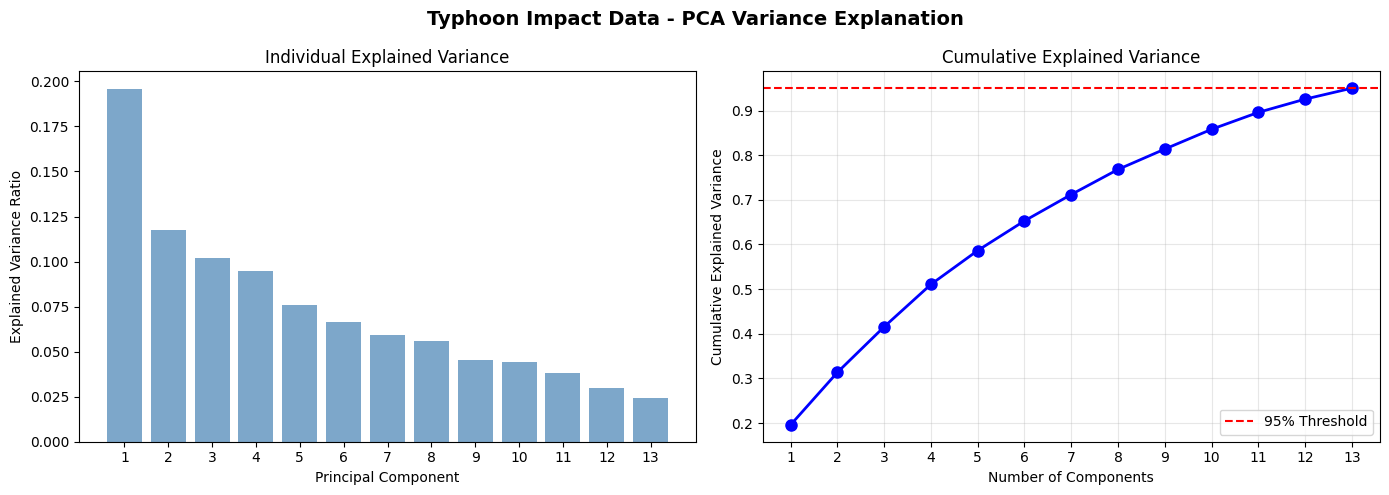

In [121]:
# Run PCA pipeline on typhoon impact data
typhoon_pca_results = run_complete_pca_pipeline(
    input_dataframe=df,
    n_components=None,  # Auto-determine based on variance threshold
    variance_threshold=0.95,
    categorical_columns=None,  # Include all columns (typhoon_type is now ordinal encoded)
    show_plots=True,
    return_loadings=True
)

In [122]:
# Access PCA results
typhoon_pca_df = typhoon_pca_results['pca_dataframe']

# Display explained variance information
print("=" * 60)
print("PCA EXPLAINED VARIANCE SUMMARY")
print("=" * 60)
print(f"Total samples: {len(typhoon_pca_df)}")
print(f"Number of PCA components: {typhoon_pca_df.shape[1]}")
print(f"Total variance explained: {typhoon_pca_results['total_variance_explained']*100:.2f}%")
print("\nVariance explained per component:")
for i, var in enumerate(typhoon_pca_results['explained_variance']):
    print(f"  PC{i+1}: {var*100:.2f}%")
print("=" * 60)

PCA EXPLAINED VARIANCE SUMMARY
Total samples: 1776
Number of PCA components: 13
Total variance explained: 95.02%

Variance explained per component:
  PC1: 19.58%
  PC2: 11.76%
  PC3: 10.22%
  PC4: 9.50%
  PC5: 7.59%
  PC6: 6.65%
  PC7: 5.90%
  PC8: 5.62%
  PC9: 4.56%
  PC10: 4.43%
  PC11: 3.79%
  PC12: 2.97%
  PC13: 2.45%


## Plotting 2D and 3D

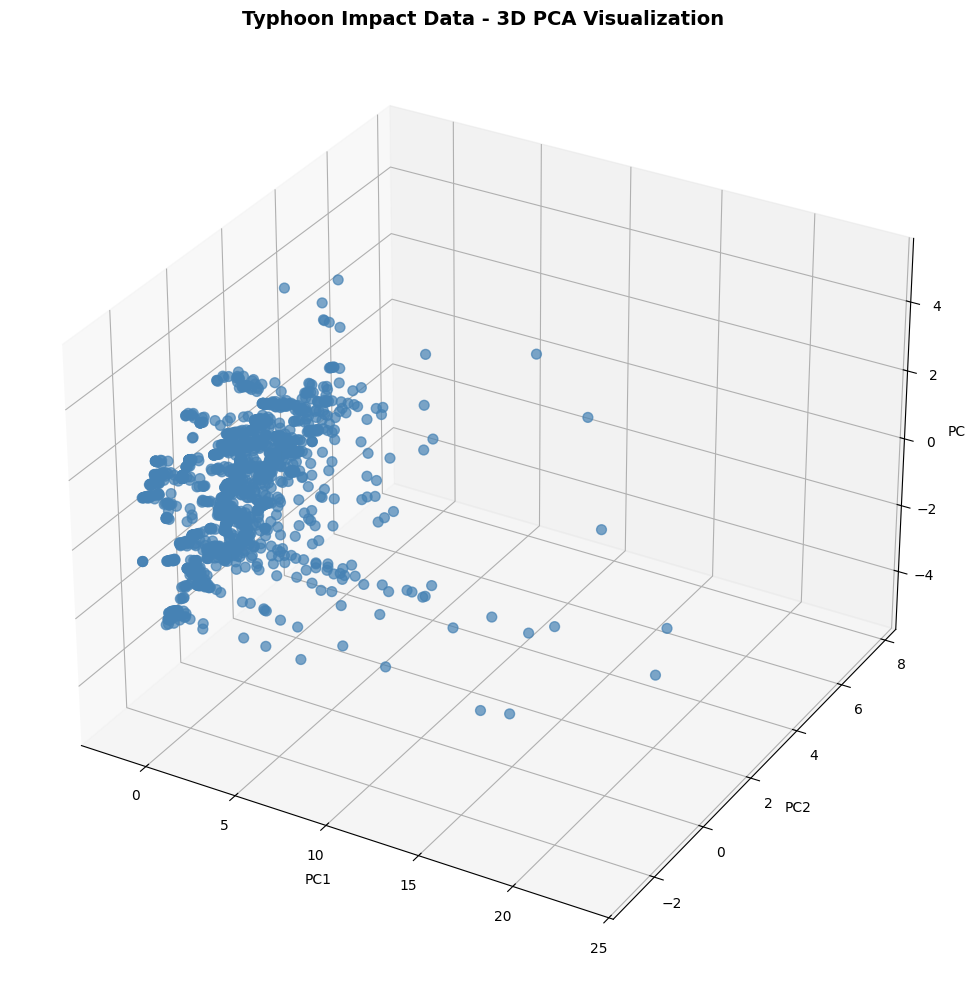

In [123]:
# 3D PCA Visualization
from mpl_toolkits.mplot3d import Axes3D

def plot_pca_3d(
    pca_dataframe: pd.DataFrame,
    cluster_labels: np.ndarray = None,
    figure_title: str = 'PCA 3D Visualization'
) -> None:
    """
    Create a 3D scatter plot of the first 3 PCA components.
    
    Parameters:
    -----------
    pca_dataframe : pd.DataFrame
        DataFrame containing PCA components (PC1, PC2, PC3)
    cluster_labels : np.ndarray, optional
        Cluster labels for coloring points
    figure_title : str
        Title for the 3D plot
    """
    pca_3d_fig = plt.figure(figsize=(12, 10))
    pca_3d_ax = pca_3d_fig.add_subplot(111, projection='3d')
    
    pc1_values = pca_dataframe['PC1'].values
    pc2_values = pca_dataframe['PC2'].values
    pc3_values = pca_dataframe['PC3'].values
    
    if cluster_labels is not None:
        scatter_plot = pca_3d_ax.scatter(
            pc1_values, pc2_values, pc3_values,
            c=cluster_labels, cmap='viridis', s=50, alpha=0.7
        )
        pca_3d_fig.colorbar(scatter_plot, ax=pca_3d_ax, label='Cluster')
    else:
        pca_3d_ax.scatter(
            pc1_values, pc2_values, pc3_values,
            c='steelblue', s=50, alpha=0.7
        )
    
    pca_3d_ax.set_xlabel('PC1')
    pca_3d_ax.set_ylabel('PC2')
    pca_3d_ax.set_zlabel('PC3')
    pca_3d_ax.set_title(figure_title, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    plt.close(pca_3d_fig)

# Plot 3D PCA visualization
plot_pca_3d(typhoon_pca_df, figure_title='Typhoon Impact Data - 3D PCA Visualization')

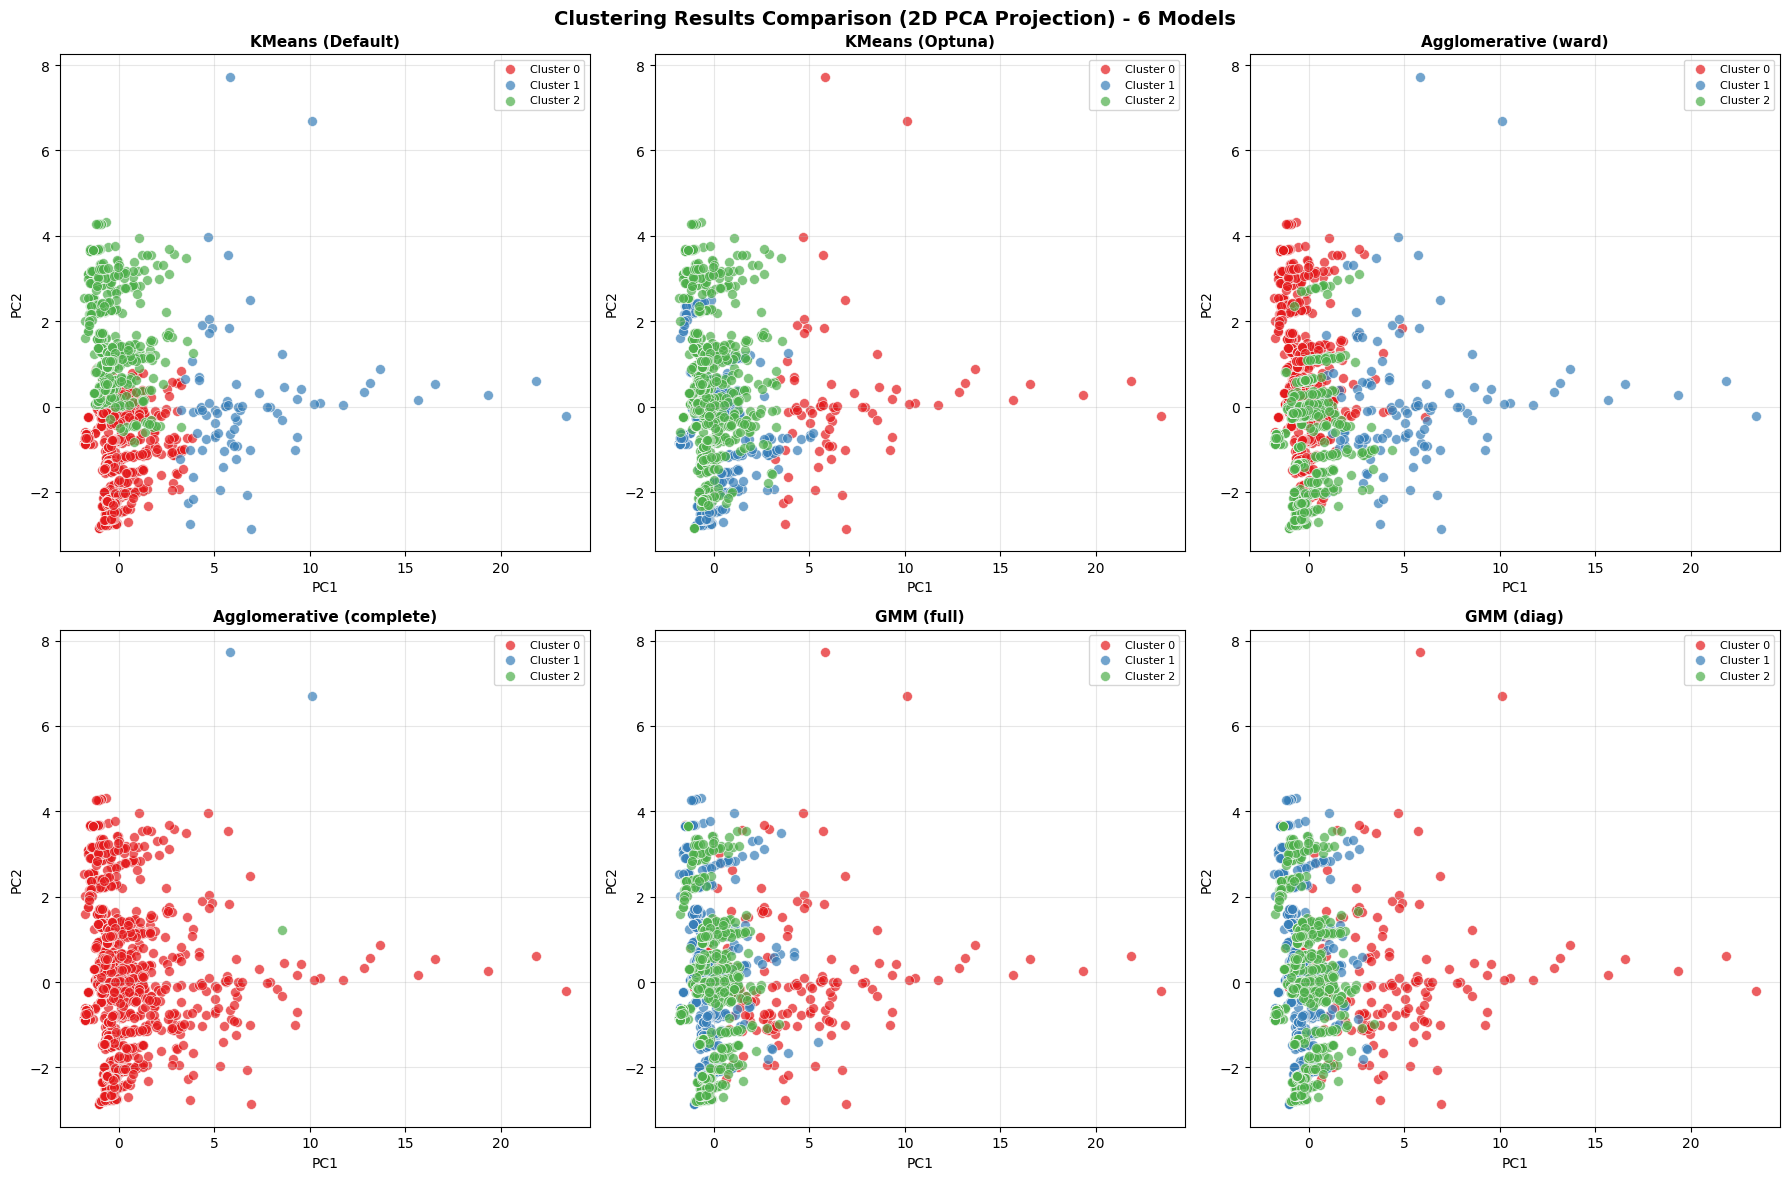

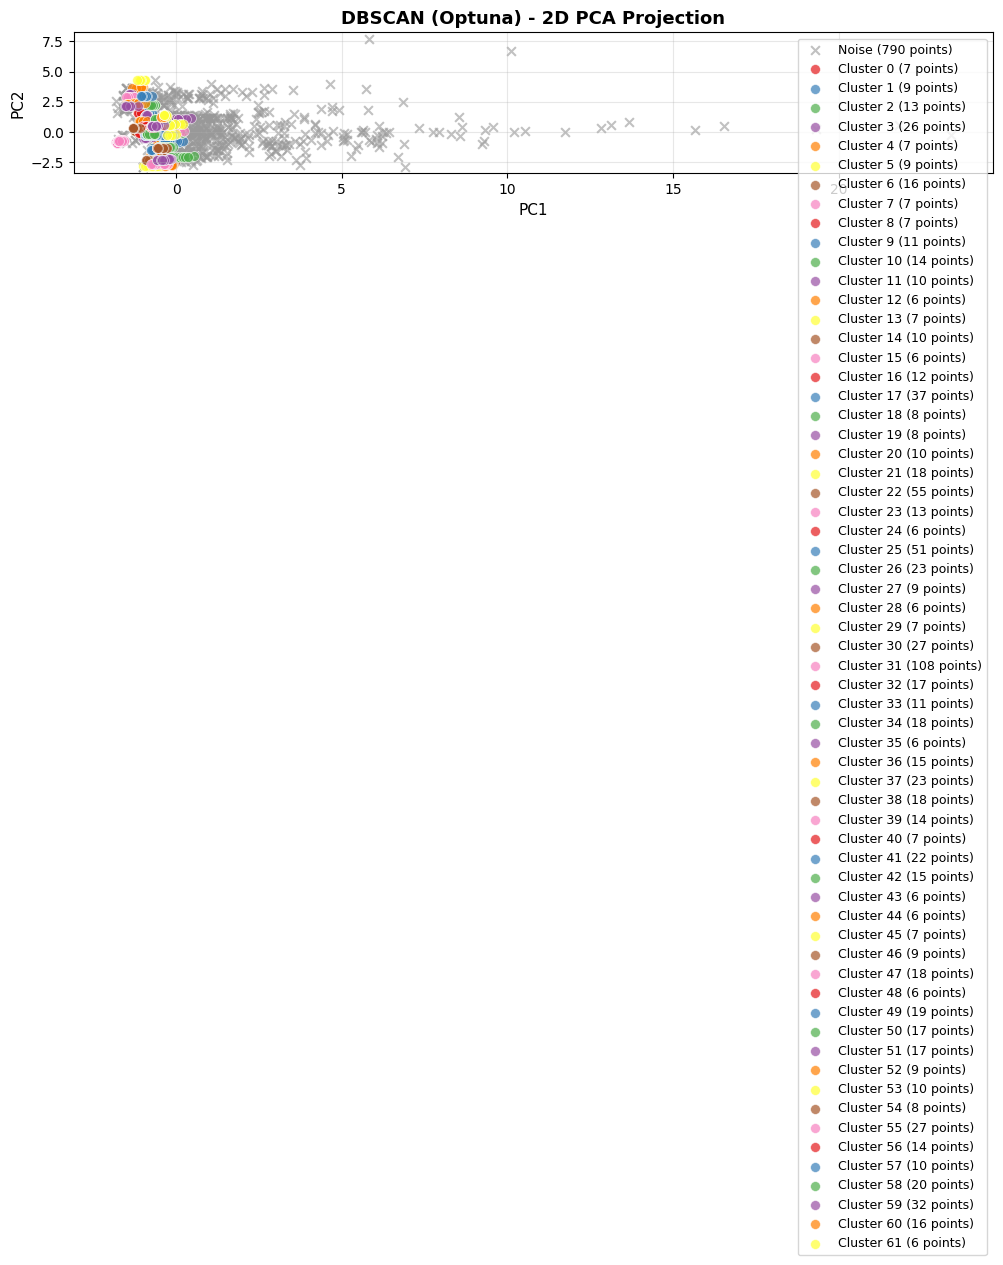

In [124]:
# Visualize cluster assignments from different models (2D PCA) - Excluding DBSCAN
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Models without DBSCAN (6 models in 2x3 grid)
models_to_plot = [
    ('KMeans (Default)', model_labels['KMeans (Default)']),
    ('KMeans (Optuna)', model_labels['KMeans (Optuna)']),
    ('Agglomerative (ward)', model_labels['Agglomerative (ward)']),
    ('Agglomerative (complete)', model_labels['Agglomerative (complete)']),
    ('GMM (full)', model_labels['GMM (full)']),
    ('GMM (diag)', model_labels['GMM (diag)'])
]

# Get PCA components for visualization
pca_vis = typhoon_pca_df[['PC1', 'PC2']].values

# Define highly distinguishable colors for clusters
cluster_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33', '#a65628', '#f781bf']

for idx, (model_name, labels) in enumerate(models_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    unique_labels = np.unique(labels)
    
    for i, label in enumerate(unique_labels):
        mask = labels == label
        color = cluster_colors[i % len(cluster_colors)]
        ax.scatter(pca_vis[mask, 0], pca_vis[mask, 1],
                  c=color, s=50, alpha=0.7, label=f'Cluster {label}', edgecolors='white', linewidth=0.5)
    
    ax.set_xlabel('PC1', fontsize=10)
    ax.set_ylabel('PC2', fontsize=10)
    ax.set_title(f'{model_name}', fontsize=11, fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Clustering Results Comparison (2D PCA Projection) - 6 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close(fig)

# Separate DBSCAN 2D Plot
fig_dbscan, ax_dbscan = plt.subplots(figsize=(10, 8))

dbscan_labels_plot = model_labels['DBSCAN (Optuna)']
unique_labels = np.unique(dbscan_labels_plot)

for i, label in enumerate(unique_labels):
    mask = dbscan_labels_plot == label
    if label == -1:
        ax_dbscan.scatter(pca_vis[mask, 0], pca_vis[mask, 1], 
                  c='#999999', marker='x', s=40, alpha=0.6, label=f'Noise ({np.sum(mask)} points)')
    else:
        color = cluster_colors[label % len(cluster_colors)]
        ax_dbscan.scatter(pca_vis[mask, 0], pca_vis[mask, 1],
                  c=color, s=50, alpha=0.7, label=f'Cluster {label} ({np.sum(mask)} points)', edgecolors='white', linewidth=0.5)

ax_dbscan.set_xlabel('PC1', fontsize=11)
ax_dbscan.set_ylabel('PC2', fontsize=11)
ax_dbscan.set_title('DBSCAN (Optuna) - 2D PCA Projection', fontsize=13, fontweight='bold')
ax_dbscan.legend(loc='best', fontsize=9)
ax_dbscan.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig_dbscan)

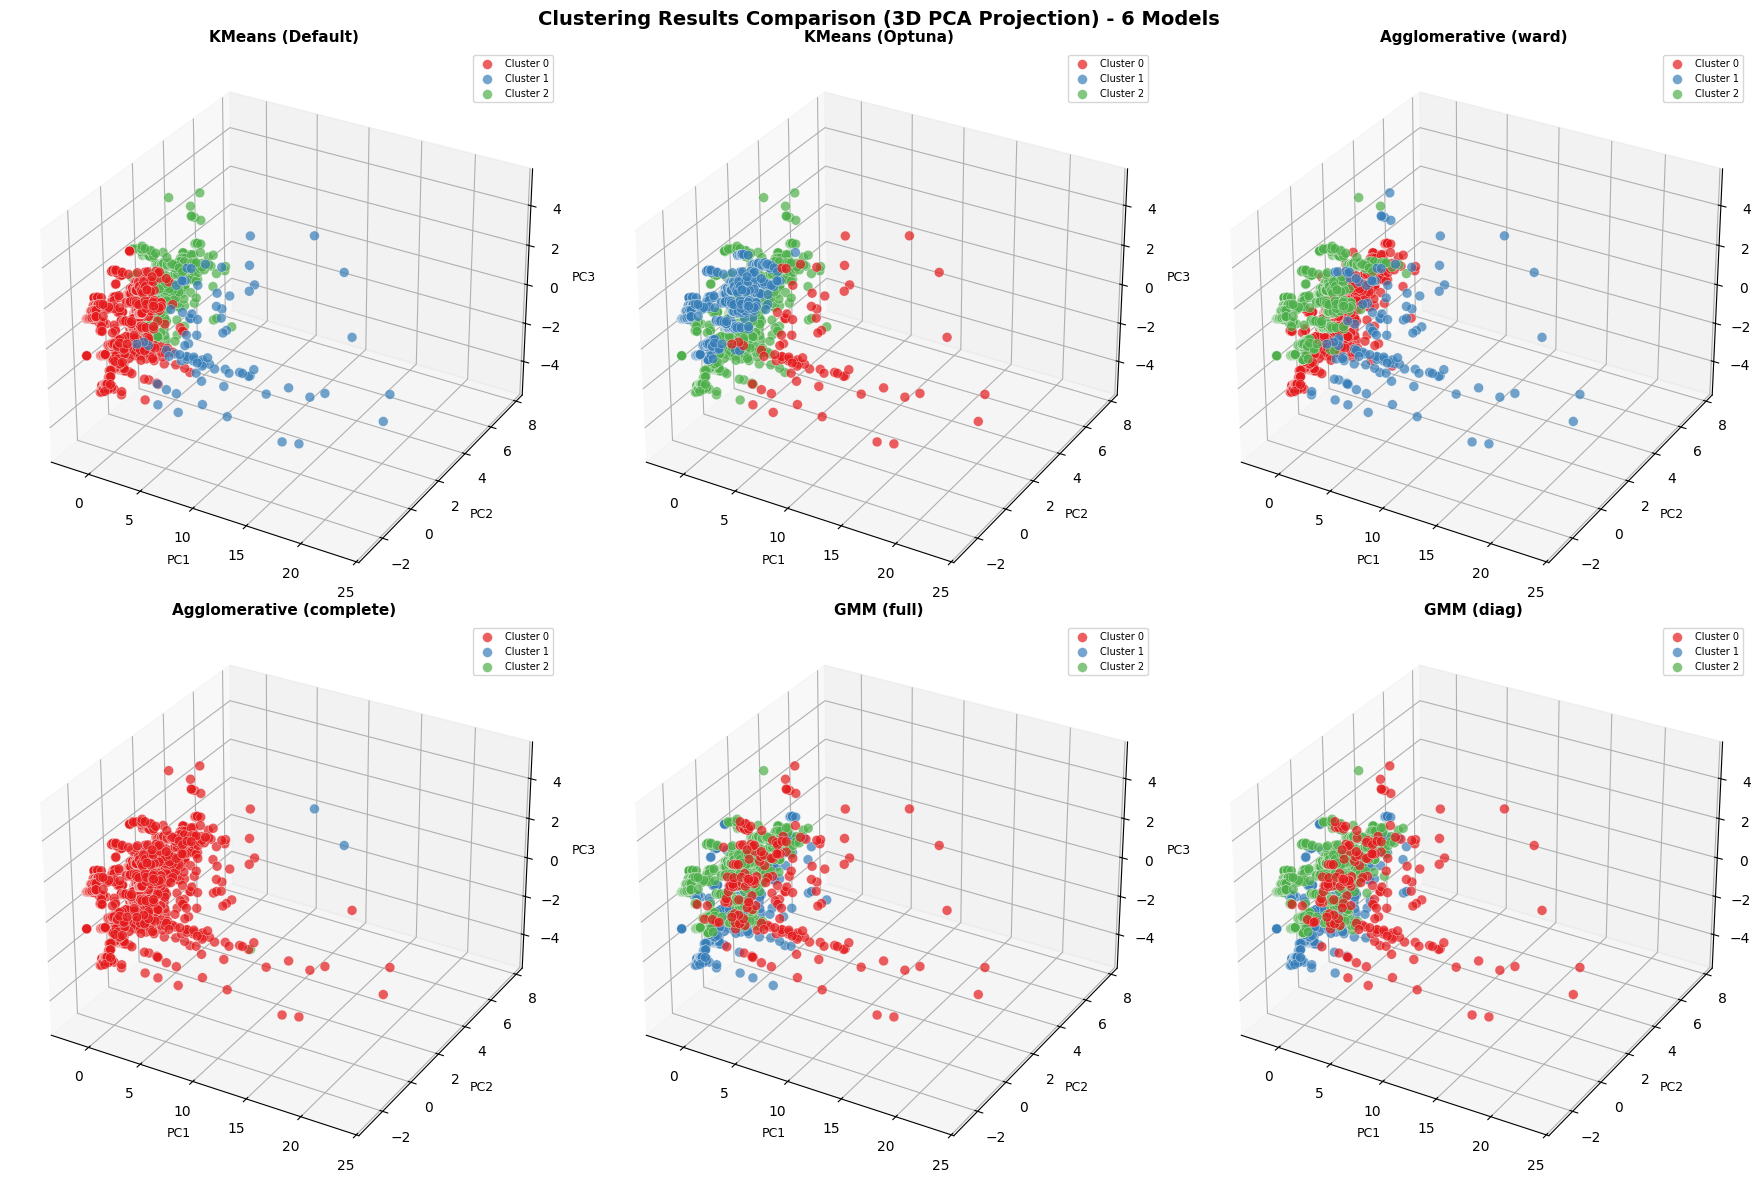

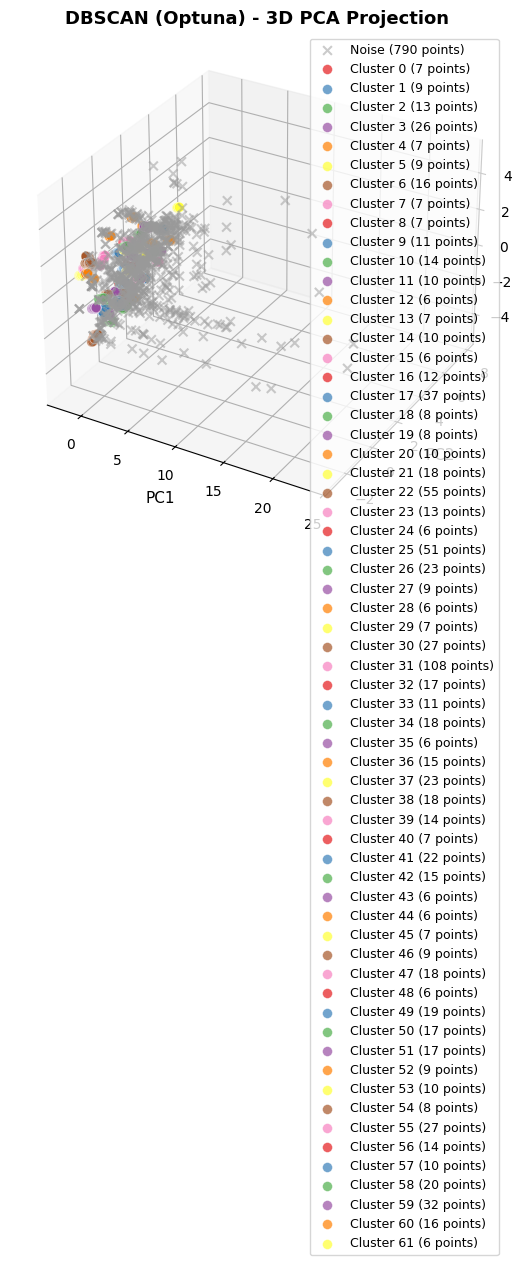

In [125]:
# 3D PCA Visualization Comparison - Excluding DBSCAN (6 models in 2x3 grid)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(18, 12))

# Models without DBSCAN
models_to_plot_3d = [
    ('KMeans (Default)', model_labels['KMeans (Default)']),
    ('KMeans (Optuna)', model_labels['KMeans (Optuna)']),
    ('Agglomerative (ward)', model_labels['Agglomerative (ward)']),
    ('Agglomerative (complete)', model_labels['Agglomerative (complete)']),
    ('GMM (full)', model_labels['GMM (full)']),
    ('GMM (diag)', model_labels['GMM (diag)'])
]

# Get PCA components for 3D visualization
pca_3d_vis = typhoon_pca_df[['PC1', 'PC2', 'PC3']].values

# Define highly distinguishable colors for clusters
cluster_colors_3d = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33', '#a65628', '#f781bf']

for idx, (model_name, labels) in enumerate(models_to_plot_3d):
    ax = fig.add_subplot(2, 3, idx + 1, projection='3d')
    
    unique_labels = np.unique(labels)
    
    for i, label in enumerate(unique_labels):
        mask = labels == label
        color = cluster_colors_3d[i % len(cluster_colors_3d)]
        ax.scatter(pca_3d_vis[mask, 0], pca_3d_vis[mask, 1], pca_3d_vis[mask, 2],
                  c=color, s=50, alpha=0.7, label=f'Cluster {label}', edgecolors='white', linewidth=0.3)
    
    ax.set_xlabel('PC1', fontsize=9)
    ax.set_ylabel('PC2', fontsize=9)
    ax.set_zlabel('PC3', fontsize=9)
    ax.set_title(f'{model_name}', fontsize=11, fontweight='bold')
    ax.legend(loc='best', fontsize=7)

plt.suptitle('Clustering Results Comparison (3D PCA Projection) - 6 Models', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
plt.close(fig)

# Separate DBSCAN 3D Plot
fig_dbscan_3d = plt.figure(figsize=(12, 10))
ax_dbscan_3d = fig_dbscan_3d.add_subplot(111, projection='3d')

dbscan_labels_3d = model_labels['DBSCAN (Optuna)']
unique_labels_3d = np.unique(dbscan_labels_3d)

for i, label in enumerate(unique_labels_3d):
    mask = dbscan_labels_3d == label
    if label == -1:
        ax_dbscan_3d.scatter(pca_3d_vis[mask, 0], pca_3d_vis[mask, 1], pca_3d_vis[mask, 2],
                  c='#999999', marker='x', s=40, alpha=0.5, label=f'Noise ({np.sum(mask)} points)')
    else:
        color = cluster_colors_3d[label % len(cluster_colors_3d)]
        ax_dbscan_3d.scatter(pca_3d_vis[mask, 0], pca_3d_vis[mask, 1], pca_3d_vis[mask, 2],
                  c=color, s=50, alpha=0.7, label=f'Cluster {label} ({np.sum(mask)} points)', edgecolors='white', linewidth=0.3)

ax_dbscan_3d.set_xlabel('PC1', fontsize=11)
ax_dbscan_3d.set_ylabel('PC2', fontsize=11)
ax_dbscan_3d.set_zlabel('PC3', fontsize=11)
ax_dbscan_3d.set_title('DBSCAN (Optuna) - 3D PCA Projection', fontsize=13, fontweight='bold')
ax_dbscan_3d.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()
plt.close(fig_dbscan_3d)

In [126]:
# Final Model Ranking with All 7 Key Models
print("=" * 80)
print("FINAL MODEL RANKING - ALL 7 KEY MODELS")
print("=" * 80)

# Recalculate combined scores for final ranking
final_ranking = comparison_subset.copy()
final_ranking['combined_score'] = combined_score
final_ranking = final_ranking.sort_values('combined_score', ascending=False)

print("\nRanking by Combined Normalized Score:")
print("-" * 80)
for rank, (_, row) in enumerate(final_ranking.iterrows(), 1):
    print(f"{rank}. {row['model']}")
    print(f"   Silhouette: {row['silhouette']:.4f} | Calinski-H: {row['calinski_harabasz']:.2f} | Davies-B: {row['davies_bouldin']:.4f}")
    print()

best_model = final_ranking.iloc[0]['model']
print(f"\n{'='*80}")
print(f"RECOMMENDED MODEL: {best_model}")
print(f"{'='*80}")

FINAL MODEL RANKING - ALL 7 KEY MODELS

Ranking by Combined Normalized Score:
--------------------------------------------------------------------------------
1. DBSCAN (Optuna)
   Silhouette: 0.7091 | Calinski-H: 1763.69 | Davies-B: 0.4470

2. Agglomerative (complete)
   Silhouette: 0.8312 | Calinski-H: 89.28 | Davies-B: 0.3744

3. KMeans (Optuna)
   Silhouette: 0.1479 | Calinski-H: 225.33 | Davies-B: 2.0925

4. KMeans (Default)
   Silhouette: 0.1403 | Calinski-H: 220.34 | Davies-B: 2.1803

5. Agglomerative (ward)
   Silhouette: 0.1340 | Calinski-H: 193.62 | Davies-B: 2.2735

6. GMM (diag)
   Silhouette: 0.1274 | Calinski-H: 164.96 | Davies-B: 2.3720

7. GMM (full)
   Silhouette: 0.1277 | Calinski-H: 161.12 | Davies-B: 2.3880


RECOMMENDED MODEL: DBSCAN (Optuna)
